In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/Colab Notebooks/data'))

['Financials.csv', 'sales_profit_timeline.png', 'Financials_cleaned.csv', 'sales_profit.png', 'financials.db', 'Finance Data Analysis.ipynb']


In [ ]:
os.chdir('/content/drive/MyDrive/Colab Notebooks/data')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/data


# **Clean data with Pandas**

 **Step 1: Data Exploration**

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('Financials.csv')

In [ ]:
print("Shape:", df.shape)
print("\nColumn names (raw):")
for c in df.columns:
    print(repr(c)) # repr() shows hidden whitespace

Shape: (700, 16)

Column names (raw):
'Segment'
'Country'
' Product '
' Discount Band '
' Units Sold '
' Manufacturing Price '
' Sale Price '
' Gross Sales '
' Discounts '
'  Sales '
' COGS '
' Profit '
'Date'
'Month Number'
' Month Name '
'Year'


**`Step 2: Clean Column Names`**

In [ ]:
df.columns = (
    df.columns
    .str.strip() # Strip whitespace from every column name
    .str.replace(' ', '_') # turns remaining internal spaces into underscores
)

In [ ]:
print(df.columns.tolist())

['Segment', 'Country', 'Product', 'Discount_Band', 'Units_Sold', 'Manufacturing_Price', 'Sale_Price', 'Gross_Sales', 'Discounts', 'Sales', 'COGS', 'Profit', 'Date', 'Month_Number', 'Month_Name', 'Year']


**Step 3: Clean Column Object (text columns)**

In [ ]:
print(df.dtypes)

Segment                object
Country                object
Product                object
Discount_Band          object
Units_Sold             object
Manufacturing_Price    object
Sale_Price             object
Gross_Sales            object
Discounts              object
Sales                  object
COGS                   object
Profit                 object
Date                   object
Month_Number            int64
Month_Name             object
Year                    int64
dtype: object


In [ ]:
obj_cols = df.select_dtypes(include='object').columns

for col in obj_cols:
    extra_spaces = df[col].astype(str) != df[col].astype(str).str.strip()

    if extra_spaces.any():
        print(f"{col}: {extra_spaces.sum()} rows have extra spaces")

Product: 700 rows have extra spaces
Discount_Band: 700 rows have extra spaces
Units_Sold: 700 rows have extra spaces
Manufacturing_Price: 700 rows have extra spaces
Sale_Price: 700 rows have extra spaces
Gross_Sales: 700 rows have extra spaces
Discounts: 700 rows have extra spaces
Sales: 700 rows have extra spaces
COGS: 700 rows have extra spaces
Profit: 700 rows have extra spaces
Month_Name: 700 rows have extra spaces


In [ ]:
print(repr(df.loc[0, 'Product']))
#repr() is a great debugging tool because it shows hidden characters like spaces.

' Carretera '


In [ ]:
#removes those extra spaces from every text column's value
for col in obj_cols:
    df[col] = (
        df[col]
        .str.strip()
    )

**Step 3b: Check for Missing Values & Duplicates across the whole dataset**

In [ ]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of exact duplicate rows:", df.duplicated().sum())

Missing values per column:
Segment                 0
Country                 0
Product                 0
Discount_Band          53
Units_Sold              0
Manufacturing_Price     0
Sale_Price              0
Gross_Sales             0
Discounts               0
Sales                   0
COGS                    0
Profit                  0
Date                    0
Month_Number            0
Month_Name              0
Year                    0
dtype: int64

Number of exact duplicate rows: 0


**Step 4: Clean the Numeric Columns**

In [ ]:
# Columns that need currency cleanup
money_cols = ['Units_Sold', 'Manufacturing_Price', 'Sale_Price',
              'Gross_Sales', 'Discounts', 'Sales', 'COGS', 'Profit']

In [ ]:
print(df[money_cols].dtypes)

Units_Sold             object
Manufacturing_Price    object
Sale_Price             object
Gross_Sales            object
Discounts              object
Sales                  object
COGS                   object
Profit                 object
dtype: object


In [ ]:
#Find values that are NOT normal currency values.
##did this since unexcepted (667) values
for col in money_cols:
    bad = ~df[col].astype(str).str.match(
        r'^\$[\d,]+(\.\d+)?$',
        na=False
    )

    if bad.any():
        print(f"\n{col} has unusual values:")
        print(df.loc[bad, col].unique()[:5])

In [ ]:
for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)   # Convert every column to string first
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace('-', '0', regex=False) # "$-" means zero, not negative
        .str.replace(r'^\((.*)\)$', r'-\1', regex=True) #Since Accountants use parentheses to indicate negative amounts.
        .astype(float)   # float, not int — Sale_Price has cents
    )

print(df[money_cols].dtypes)
print(df[money_cols].head(3))

Units_Sold             float64
Manufacturing_Price    float64
Sale_Price             float64
Gross_Sales            float64
Discounts              float64
Sales                  float64
COGS                   float64
Profit                 float64
dtype: object
   Units_Sold  Manufacturing_Price  Sale_Price  Gross_Sales  Discounts  \
0      1618.5                  3.0        20.0      32370.0        0.0   
1      1321.0                  3.0        20.0      26420.0        0.0   
2      2178.0                  3.0        15.0      32670.0        0.0   

     Sales     COGS   Profit  
0  32370.0  16185.0  16185.0  
1  26420.0  13210.0  13210.0  
2  32670.0  21780.0  10890.0  


In [ ]:
print('Any negative Profit?', (df.Profit < 0).sum())
print('Any nulls after conversion?')
print(df[money_cols].isnull().sum().sum())

Any negative Profit? 58
Any nulls after conversion?
0


In [ ]:
print(df[money_cols].describe().round(2))


       Units_Sold  Manufacturing_Price  Sale_Price  Gross_Sales  Discounts  \
count      700.00               700.00      700.00       700.00     700.00   
mean      1608.29                96.48      118.43    182759.43   13150.35   
std        867.43               108.60      136.78    254262.28   22962.93   
min        200.00                 3.00        7.00      1799.00       0.00   
25%        905.00                 5.00       12.00     17391.75     800.32   
50%       1542.50                10.00       20.00     37980.00    2585.25   
75%       2229.12               250.00      300.00    279025.00   15956.35   
max       4492.50               260.00      350.00   1207500.00  149677.50   

            Sales       COGS     Profit  
count      700.00     700.00     700.00  
mean    169609.07  145475.21   24133.86  
std     236726.35  203865.51   42760.63  
min       1655.08     918.00  -40617.50  
25%      15928.00    7490.00    2805.96  
50%      35540.20   22506.25    9242.20  
75%

**Step 5: Fix Date Columns**

In [ ]:
print(df['Date'].head(10))

0    01/01/2014
1    01/01/2014
2    01/06/2014
3    01/06/2014
4    01/06/2014
5    01/12/2014
6    01/03/2014
7    01/06/2014
8    01/06/2014
9    01/06/2014
Name: Date, dtype: object


In [ ]:
# rebuild Date safely from Year + Month_Number
df['Date'] = pd.to_datetime(dict(year=df.Year, month=df.Month_Number, day=1))

In [ ]:
print(df.dtypes)
print()
print(df.head(3).to_string())

Segment                        object
Country                        object
Product                        object
Discount_Band                  object
Units_Sold                    float64
Manufacturing_Price           float64
Sale_Price                    float64
Gross_Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[ns]
Month_Number                    int64
Month_Name                     object
Year                            int64
dtype: object

      Segment  Country    Product Discount_Band  Units_Sold  Manufacturing_Price  Sale_Price  Gross_Sales  Discounts    Sales     COGS   Profit       Date  Month_Number Month_Name  Year
0  Government   Canada  Carretera          None      1618.5                  3.0        20.0      32370.0        0.0  32370.0  16185.0  16185.0 2014-01-01             1    January  2014
1  Go

**Step 6 : Save Clean Data**

In [ ]:
df.to_csv('Financials_cleaned.csv', index=False)
print('Saved:', df.shape)

Saved: (700, 16)


# **Load cleaned data into SQLite**

In [ ]:
import sqlite3

**Step 1: Create a SQLite database**

In [ ]:
df = pd.read_csv('Financials_cleaned.csv', parse_dates=['Date'])

In [ ]:
#creates a SQLite database (or opens it if it already exists).
conn = sqlite3.connect("financials.db")

**Step 2:Load the dataframe into SQLite**

In [ ]:
#dataframe is stored as a SQL table named financials.
df.to_sql('financials', conn, if_exists='replace', index=False)

700

#sanity check
cur = conn.cursor()
cur.execute('SELECT COUNT(*) FROM financials')
print('Rows loaded:', cur.fetchone()[0])
cur.execute('PRAGMA table_info(financials)')
for row in cur.fetchall():
    print(row)
conn.close()
#REAL for money columns, TIMESTAMP for Date

In [ ]:
cur = conn.cursor()

cur.execute("""
SELECT
    Year,
    Month_Number,
    Month_Name,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Margin_Pct
FROM financials
GROUP BY Year, Month_Number, Month_Name
ORDER BY Year, Month_Number;
""")

for row in cur.fetchall():
    print(row)

(2013, 9, 'September', 4484000.03, 763603.0300000001, 17.03)
(2013, 10, 'October', 9295611.099999996, 1657795.0999999999, 17.83)
(2013, 11, 'November', 7267203.3, 765502.3, 10.53)
(2013, 12, 'December', 5368441.08, 691564.0800000001, 12.88)
(2014, 1, 'January', 6607761.69, 814028.69, 12.32)
(2014, 2, 'February', 7297531.390000001, 1148547.39, 15.74)
(2014, 3, 'March', 5586859.869999999, 669866.87, 11.99)
(2014, 4, 'April', 6964775.080000001, 929984.5799999998, 13.35)
(2014, 5, 'May', 6210211.0600000005, 828640.06, 13.34)
(2014, 6, 'June', 9518893.819999997, 1473753.8200000003, 15.48)
(2014, 7, 'July', 8102920.190000001, 923865.6899999998, 11.4)
(2014, 8, 'August', 5864622.42, 791066.4199999999, 13.49)
(2014, 9, 'September', 6398697.24, 1023132.24, 15.99)
(2014, 10, 'October', 12375819.919999994, 1781985.9200000004, 14.4)
(2014, 11, 'November', 5384214.2, 604600.2, 11.23)
(2014, 12, 'December', 11998787.900000002, 2025765.9000000008, 16.88)


**Step 3: SQL Query 1 — Total Profit by Country**

In [ ]:
# Compare total profit across countries to identify which countries
# generated the highest and lowest total profit
query = """
SELECT Country,
       SUM(Profit) AS Total_Profit
FROM financials
GROUP BY Country
ORDER BY Total_Profit DESC;
"""
result = pd.read_sql_query(query, conn)
result

,Country,Total_Profit
0,France,3781020.79
1,Germany,3680388.82
2,Canada,3529228.89
3,United States of America,2995540.68
4,Mexico,2907523.11


**Step 4: SQL Query 2 — Monthly Sales & Profit Aggregation**

In [ ]:
query = """
SELECT
    Year,
    Month_Number,
    Month_Name,
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    ROUND(SUM(Profit) * 100.0 / SUM(Sales), 2) AS Profit_Percentage
FROM financials
GROUP BY Year, Month_Number, Month_Name
ORDER BY Year, Month_Number;
"""

result = pd.read_sql_query(query, conn)

result

,Year,Month_Number,Month_Name,Total_Sales,Total_Profit,Profit_Percentage
0,2013,9,September,4484000.03,763603.03,17.03
1,2013,10,October,9295611.10,1657795.10,17.83
2,2013,11,November,7267203.30,765502.30,10.53
3,2013,12,December,5368441.08,691564.08,12.88
4,2014,1,January,6607761.69,814028.69,12.32
5,2014,2,February,7297531.39,1148547.39,15.74
6,2014,3,March,5586859.87,669866.87,11.99
7,2014,4,April,6964775.08,929984.58,13.35
8,2014,5,May,6210211.06,828640.06,13.34
9,2014,6,June,9518893.82,1473753.82,15.48


**Step 5: SQL Query 3 — Month-over-Month Variance (the "Budget Variance" logic)**

In [ ]:
print(df.dtypes)

Segment                        object
Country                        object
Product                        object
Discount_Band                  object
Units_Sold                    float64
Manufacturing_Price           float64
Sale_Price                    float64
Gross_Sales                   float64
Discounts                     float64
Sales                         float64
COGS                          float64
Profit                        float64
Date                   datetime64[ns]
Month_Number                    int64
Month_Name                     object
Year                            int64
dtype: object


In [ ]:
query = """
-- Step 1: Create temporary table called monthly
WITH monthly AS(
  SELECT
    Year,
    Month_Name,
    Month_Number,
    SUM(Sales) AS Total_Sales
  FROM financials

  GROUP BY
    Year,
    Month_Name,
    Month_Number

),
-- Step 2: Add previous month's sales
sales_data AS(
  SELECT
    *,
    LAG(Total_Sales) OVER (
      ORDER BY Year, Month_Number
    ) AS Previous_Month_Sales
  FROM monthly
)
-- Step 3: Calculate differences
SELECT
  Year,
  Month_Name,
  Total_Sales,
  Previous_Month_Sales,
  ROUND(
    Total_Sales - Previous_Month_Sales,2
  ) AS Sales_Difference,

  ROUND(
    (Total_Sales - Previous_Month_Sales) * 100.0
    /Previous_Month_Sales,2
  ) AS Sales_Difference_Percentage
FROM sales_data
ORDER BY Year, Month_Number;
"""

result = pd.read_sql_query(query, conn)
result

,Year,Month_Name,Total_Sales,Previous_Month_Sales,Sales_Difference,Sales_Difference_Percentage
0,2013,September,4484000.03,NaN,NaN,NaN
1,2013,October,9295611.10,4484000.03,4811611.07,107.31
2,2013,November,7267203.30,9295611.10,-2028407.80,-21.82
3,2013,December,5368441.08,7267203.30,-1898762.22,-26.13
4,2014,January,6607761.69,5368441.08,1239320.61,23.09
5,2014,February,7297531.39,6607761.69,689769.70,10.44
6,2014,March,5586859.87,7297531.39,-1710671.52,-23.44
7,2014,April,6964775.08,5586859.87,1377915.21,24.66
8,2014,May,6210211.06,6964775.08,-754564.02,-10.83
9,2014,June,9518893.82,6210211.06,3308682.76,53.28


**Step 6: SQL Query 4 — Where Are the Losses Coming From?**

In [ ]:
#Since we found negative
query = """
SELECT
    Segment, Country, Product,Discount_Band,
    COUNT(*) AS Loss_Transactions,
    ROUND(SUM(Profit), 2) AS Total_Loss,
    ROUND(SUM(Sales), 2) AS Related_Sales
FROM financials
WHERE Profit < 0
GROUP BY Segment, Country, Product,Discount_Band
ORDER BY Total_Loss ASC
LIMIT 10;
"""

result = pd.read_sql_query(query, conn)
result

,Segment,Country,Product,Discount_Band,Loss_Transactions,Total_Loss,Related_Sales
0,Enterprise,Canada,VTT,High,3,-77393.75,770526.25
1,Enterprise,France,Carretera,High,4,-61403.75,672996.25
2,Enterprise,Mexico,Carretera,High,2,-56822.50,540417.50
3,Enterprise,Germany,Carretera,High,2,-52965.00,409275.00
4,Enterprise,United States of America,Velo,High,2,-45492.50,438587.50
5,Enterprise,United States of America,Amarilla,High,2,-39892.50,370867.50
6,Enterprise,Germany,Amarilla,High,1,-27693.75,352106.25
7,Enterprise,United States of America,Carretera,High,1,-25841.25,387618.75
8,Enterprise,Canada,Carretera,High,1,-24160.00,265760.00
9,Enterprise,United States of America,VTT,High,1,-23870.00,262570.00


**Step 7: SQL Query 5 — Loss by Segment and Discount Band**

In [ ]:
q1 = '''
SELECT
  Segment,
  COUNT(*) AS Loss_Rows,
  ROUND(SUM(Profit),2) AS Total_Loss
FROM financials
WHERE Profit < 0
GROUP BY Segment ORDER BY Total_Loss ASC;
'''
q2 = '''
SELECT
  Discount_Band,
  COUNT(*) AS Loss_Rows,
  ROUND(SUM(Profit),2) AS Total_Loss
FROM financials
WHERE Profit < 0
GROUP BY Discount_Band
ORDER BY Total_Loss ASC;
'''
print('--- By Segment ---')
print(pd.read_sql_query(q1, conn).to_string(index=False))
print()
print('--- By Discount Band ---')
print(pd.read_sql_query(q2, conn).to_string(index=False))

--- By Segment ---
   Segment  Loss_Rows  Total_Loss
Enterprise         58  -777321.25

--- By Discount Band ---
Discount_Band  Loss_Rows  Total_Loss
         High         33  -622368.75
       Medium         25  -154952.50


# **Plot Sales & Profit Over the Timeline**

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

1.   Sales : How much money did we make from selling products?
2.   Profit : After paying all costs, how much money did we actually keep?




<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:47: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_2842/3558266071.py:25: SyntaxWarning: invalid escape sequence '\$'
  ax1.set_ylabel('Sales (\$)', color='#1f4e79')
/tmp/ipykernel_2842/3558266071.py:47: SyntaxWarning: invalid escape sequence '\$'
  ax2.set_ylabel('Profit (\$)', color='#c55a11')


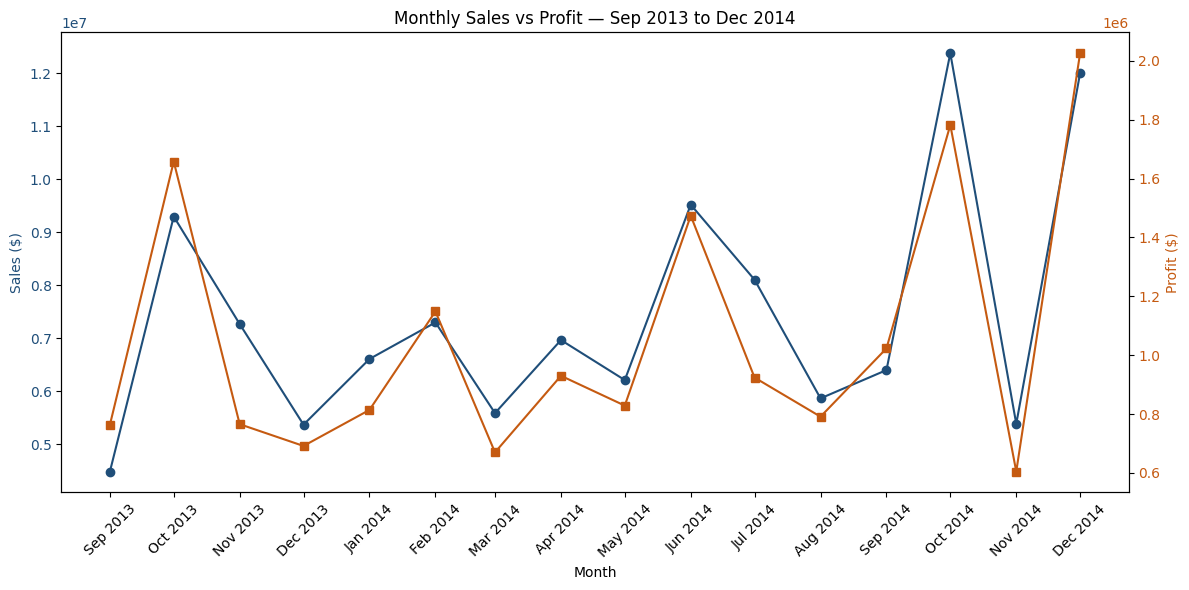

In [ ]:
# Step 1: Calculate total Sales and Profit for each month
monthly = (
    # There are many rows for the same month.
    #groupby('Date') : Groups all rows belonging to the same month.
    df.groupby('Date')[['Sales', 'Profit']]
      .sum() #Adds all Sales and Profit inside each month.
      .reset_index() #After grouping, Date becomes the index.This converts Date back into a normal column.
      .sort_values('Date') #Sorts months chronologically.
)

# Step 2: Create the figure
fig, ax1 = plt.subplots(figsize=(12,6)) #Creates the chart area.

# ---------------- SALES ----------------
# Draw Sales line.
ax1.plot(
    monthly['Date'],
    monthly['Sales'],
    color='#1f4e79',
    marker='o',
    label='Sales'
)

ax1.set_xlabel("Month")
ax1.set_ylabel('Sales (\$)', color='#1f4e79')
ax1.tick_params(axis='y', labelcolor='#1f4e79')

# Show every month on the x-axis
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

plt.xticks(rotation=45)

# ---------------- PROFIT ----------------

# Create another y-axis for Profit
ax2 = ax1.twinx()

ax2.plot(
    monthly['Date'],
    monthly['Profit'],
    color='#c55a11',
    marker='s',
    label='Profit'
)

ax2.set_ylabel('Profit (\$)', color='#c55a11')
ax2.tick_params(axis='y', labelcolor='#c55a11')

# ---------------- TITLE ----------------

plt.title("Monthly Sales vs Profit — Sep 2013 to Dec 2014")

plt.tight_layout()
plt.savefig('sales_profit.png', dpi=150, bbox_inches='tight')
plt.show()

As analysts, we usually look for five things.

1.   Is the company improving over time?
*   sales fluctuate.
*   since graph isn't a smooth upward trend.


2.   Highest month?
*   Look at the tallest blue point.
*   October 2014.
*   December 2014 is almost as high.
*   These months had the highest sales.

*   Maybe holiday season, demand increased

1.   Lowest month

*   September 2013
*   November 2014
*   fewer customers? stock shortage?

2.   Sales and Profit move together
*   When Sales go up Profit usually goes up.
*   That tells us Higher sales generally lead to higher profit.

1.   Profit Margin
*   the orange line stays fairly proportional to the blue line.
That's a good sign.


2.   Things to notice
*   October 2014 Huge increase.Both Sales and Profit spike.
*   November 2014 Both crash immediately.
*   Sales and Profit almost always move in the same direction.
*   The company isn't increasing sales by sacrificing profit.








